Importing libraries

In [9]:
# Tensorflow and Keras
from tensorflow.keras import Sequential
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Flatten

# Matplotlib and numpy
import matplotlib.pyplot as plt
import numpy as np

# sklearn
from sklearn.metrics import accuracy_score

Importing MNIST dataset

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape)
print(y_train)

(60000, 28, 28)
[5 0 4 ... 5 6 8]


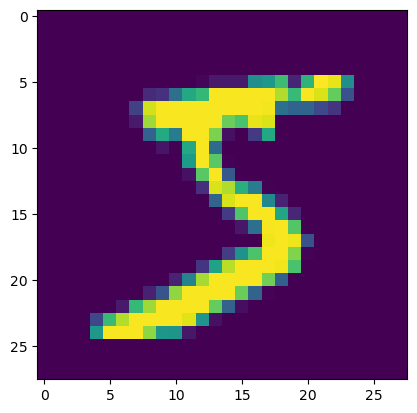

In [3]:
plt.imshow(X_train[0])
plt.show()

In [3]:
print(np.max(X_train))

# Normalisation
X_train, X_test = X_train/255, X_test/255
print(X_train[0])

255
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.

Preparing the Neural Network

In [5]:
model1 = Sequential([Flatten(input_shape=(28, 28)),
                   Dense(128, activation='relu'),
                   Dense(32, activation='relu'),
                   Dense(10, activation='softmax')])

model1.summary()

c:\Users\ARYA BASAK\miniconda3\envs\DSML\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

Training the NN

In [6]:
model1.compile(loss='sparse_categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
history1 = model1.fit(X_train, y_train, epochs = 50, validation_split=0.2)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9165 - loss: 0.2876 - val_accuracy: 0.9572 - val_loss: 0.1435
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9641 - loss: 0.1210 - val_accuracy: 0.9672 - val_loss: 0.1118
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9748 - loss: 0.0823 - val_accuracy: 0.9678 - val_loss: 0.1072
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9806 - loss: 0.0616 - val_accuracy: 0.9724 - val_loss: 0.0975
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9856 - loss: 0.0470 - val_accuracy: 0.9715 - val_loss: 0.0979
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9879 - loss: 0.0385 - val_accuracy: 0.9736 - val_loss: 0.0965
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9904 - loss: 0.0308 - val_accuracy: 0.9725 - val_loss: 0.0993
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9914 - loss: 0.0272 - 

Plotting model metrics

NameError: name 'history1' is not defined

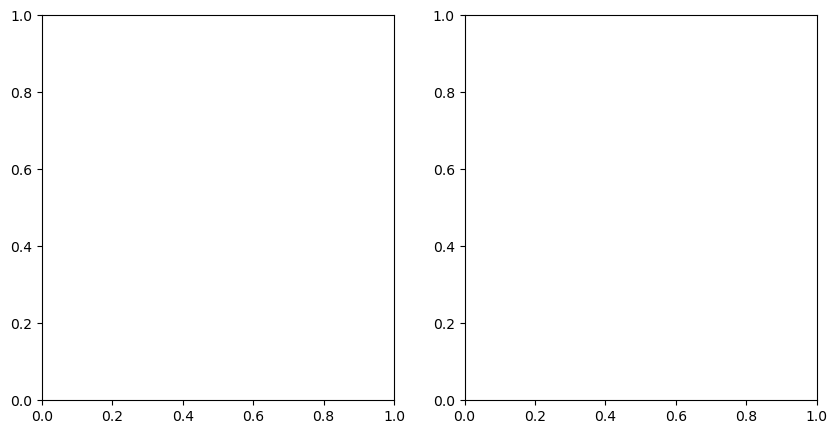

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Loss
ax[0].plot(history1.history['loss'], color='blue', label='Loss')
ax[0].plot(history1.history['val_loss'], color='orange', label='Validation loss')
ax[0].set_title("Loss over epochs")
ax[0].set_ylabel("Loss")
ax[0].set_xlabel("Epochs")
ax[0].legend()
ax[0].grid()

# Accuracy
ax[1].plot(history1.history['accuracy'], color='blue', label='Accuracy')
ax[1].plot(history1.history['val_accuracy'], color='orange', label='Validation accuracy')
ax[1].set_title("Accuracy over epochs")
ax[1].set_ylabel("Accuracy")
ax[1].set_xlabel("Epochs")
ax[1].legend()
ax[1].grid()

fig.suptitle("Model metrics")
fig.tight_layout()
plt.show()

Predicting output

In [ ]:
y_prob1 = model1.predict(X_test)
print(y_prob1.shape)

y_pred1 = y_prob1.argmax(axis=1)
print(y_pred1.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 10)
(10000,)


Checking accuracy

In [ ]:
accuracy_score(y_pred1, y_test)

0.9805

Improving the NN

In [ ]:
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Dropout layer, batch normalisation and He normal
model2 = Sequential([Flatten(input_shape=(28, 28)),
                   Dense(128, activation='relu', kernel_initializer='he_normal'),
				   BatchNormalization(),
                   Dropout(0.2),
                   
                   Dense(32, activation='relu', kernel_initializer='he_normal'),
                   BatchNormalization(),
                   
                   Dense(10, activation='softmax')])

model2.summary()

c:\Users\ARYA BASAK\miniconda3\envs\DSML\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,578 (412.41 KB)

 Trainable params: 105,258 (411.16 KB)

 Non-trainable params: 320 (1.25 KB)

In [5]:
# Early stopping
callback = EarlyStopping(monitor='val_loss',
                         min_delta = 1e-4,
                         patience=20,
                         verbose=1,
                         mode='auto',
                         baseline=None,
                         restore_best_weights=True)

model2.compile(loss='sparse_categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
history2 = model2.fit(X_train, y_train, validation_split=0.2, epochs=50, callbacks=callback)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8878 - loss: 0.3839 - val_accuracy: 0.9557 - val_loss: 0.1511
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9367 - loss: 0.2063 - val_accuracy: 0.9622 - val_loss: 0.1259
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9481 - loss: 0.1704 - val_accuracy: 0.9674 - val_loss: 0.1104
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9542 - loss: 0.1475 - val_accuracy: 0.9729 - val_loss: 0.0952
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9586 - loss: 0.1337 - val_accuracy: 0.9716 - val_loss: 0.0934
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9639 - loss: 0.1179 - val_accuracy: 0.9725 - val_loss: 0.0947
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9647 - loss: 0.1109 - val_accuracy: 0.9736 - val_loss: 0.0937
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9663 - loss: 0.1051 

Predicting output and accuracy

In [ ]:
y_prob2 = model2.predict(X_test)
y_pred2 = y_prob2.argmax(axis=1)

accuracy_score(y_pred2, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


0.9805

Plotting

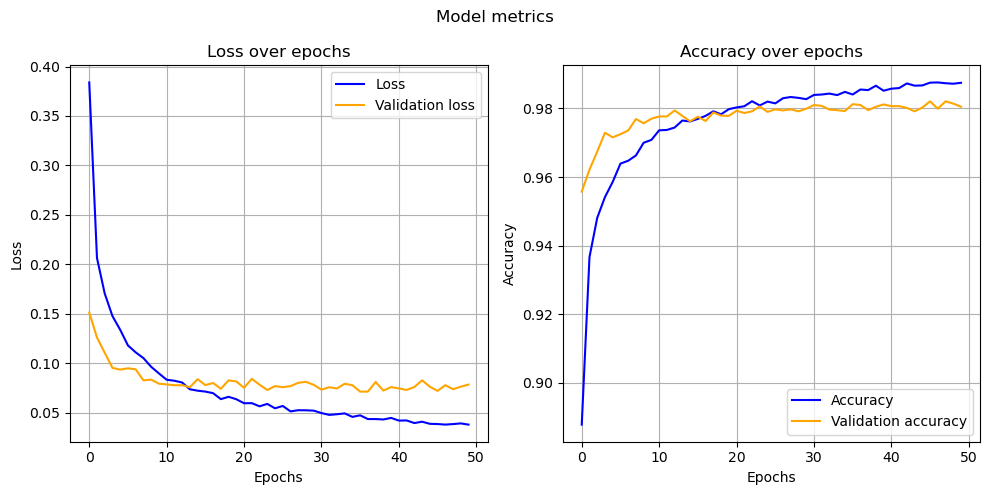

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Loss
ax[0].plot(history2.history['loss'], color='blue', label='Loss')
ax[0].plot(history2.history['val_loss'], color='orange', label='Validation loss')
ax[0].set_title("Loss over epochs")
ax[0].set_ylabel("Loss")
ax[0].set_xlabel("Epochs")
ax[0].legend()
ax[0].grid()

# Accuracy
ax[1].plot(history2.history['accuracy'], color='blue', label='Accuracy')
ax[1].plot(history2.history['val_accuracy'], color='orange', label='Validation accuracy')
ax[1].set_title("Accuracy over epochs")
ax[1].set_ylabel("Accuracy")
ax[1].set_xlabel("Epochs")
ax[1].legend()
ax[1].grid()

fig.suptitle("Model metrics")
fig.tight_layout()
plt.show()